# Rough Bergomi Forecasting Model

This notebook implements the Rough Bergomi forecasting framework used in the thesis.

The objective is not to simulate the full rough Bergomi model for option pricing, but rather to construct forecasting features inspired by its rough volatility dynamics.

The model combines:

- Hurst exponents estimated via the Randomized Kolmogorov–Smirnov procedure;
- fractional-memory features reflecting the roughness of volatility;
- nonlinear lognormal transformations motivated by the volatility-of-volatility component of the rough Bergomi framework.

These features are used within a predictive regression setting to generate one-day-ahead forecasts of log-realized volatility.

Model selection is performed on the validation set over:

- memory depth \(K\),
- ridge regularization parameter \(\alpha\),
- volatility-of-volatility scale \(\eta\).

Final performance is evaluated out-of-sample using QLIKE and MSE and compared against the HAR-RV benchmark and the other rough volatility models considered in the thesis.

In [1]:
# ============================================================
# ROUGH-BERGOMI-INSPIRED FORECASTING MODEL
# Master's Thesis: From Fractional to Rough Volatility
# Author: Elisa Battista
# ============================================================

from __future__ import annotations

import os
import glob
import time
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# ------------------------------------------------------------
# Google Drive Setup
# ------------------------------------------------------------

MOUNTPOINT = "/content/drive"

if not os.path.isdir(f"{MOUNTPOINT}/MyDrive"):
    drive.mount(MOUNTPOINT)

BASE = f"{MOUNTPOINT}/MyDrive/thesis"

CLEAN_DIR = f"{BASE}/data/clean"
SPLIT_DIR = f"{BASE}/data/splits"
RESULTS_DIR = f"{BASE}/results/metrics"
PRED_DIR = f"{BASE}/results/preds"
FIG_DIR = f"{BASE}/results/figures"

for folder in [RESULTS_DIR, PRED_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

RKS_CSV = f"{RESULTS_DIR}/hurst_randomizedKS_summary.csv"
RB_SUMMARY = f"{RESULTS_DIR}/rbergomi_summary.csv"
RB_LATEX = f"{RESULTS_DIR}/rbergomi_table.tex"

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

K_GRID = [60, 90, 120, 180, 210, 252, 300, 330, 360]
ALPHA_GRID = list(np.logspace(-10, -1, 10))
ETA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def log(message: str) -> None:
    print(f"[rBergomi] {message}")


def qlike_var(v_true: np.ndarray, v_pred: np.ndarray) -> float:
    eps = 1e-12
    v_true = np.clip(v_true, eps, None)
    v_pred = np.clip(v_pred, eps, None)

    ratio = v_true / v_pred

    return float(np.mean(ratio - np.log(ratio) - 1.0))


def fractional_weights(H: float, K: int) -> np.ndarray:
    """
    Volterra-type fractional kernel:

    w_j = j^(H - 1/2) - (j + 1)^(H - 1/2)

    The weights are L1-normalized for numerical stability.
    """
    if not (0 < H < 1):
        raise ValueError("H must be in (0, 1).")

    exponent = H - 0.5
    j = np.arange(1, K + 1, dtype=float)

    weights = j ** exponent - (j + 1.0) ** exponent

    denominator = np.sum(np.abs(weights))

    if denominator <= 0 or not np.isfinite(denominator):
        raise ValueError("Invalid fractional weights.")

    return weights / denominator


def build_features_logvol(log_vol: np.ndarray, H: float, K: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build rough-Bergomi-inspired features.

    Target:
    ell_{t+1}

    Features:
    Z_t and Z_t^2, where Z_t is a fractional-memory component.
    """
    weights = fractional_weights(H, K)
    T = len(log_vol)

    Z = np.zeros(T)

    for t in range(K, T):
        past_values = log_vol[t - np.arange(1, K + 1)]
        Z[t] = float(np.dot(weights, past_values))

    X = []
    y = []

    for t in range(K, T - 1):
        z_t = Z[t]
        X.append([z_t, z_t ** 2])
        y.append(log_vol[t + 1])

    return np.asarray(X, dtype=float), np.asarray(y, dtype=float)


def discover_clean_files(clean_dir: str) -> Dict[str, str]:
    paths = sorted(glob.glob(os.path.join(clean_dir, "data_clean_*.csv")))
    files = {}

    for path in paths:
        try:
            head = pd.read_csv(path, nrows=5)

            if "Symbol" in head.columns and "Date" in head.columns:
                symbol = str(head["Symbol"].dropna().iloc[0]).strip()
                files[symbol] = path

        except Exception:
            pass

    return files


def load_hurst_map(path: str) -> Dict[str, float]:
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"Missing Hurst file: {path}. Run 02_hurst_estimation.ipynb first."
        )

    df = pd.read_csv(path)

    symbol_col = next(
        (col for col in ["Symbol", "symbol", "Ticker", "Index"] if col in df.columns),
        None
    )

    h_col = next(
        (col for col in ["H_hat_KS", "H", "H_RKS", "Hurst"] if col in df.columns),
        None
    )

    if symbol_col is None or h_col is None:
        raise ValueError("Hurst CSV must contain columns similar to Symbol and H_hat_KS.")

    return dict(
        zip(
            df[symbol_col].astype(str).str.strip(),
            df[h_col].astype(float)
        )
    )


def load_split_from_npz(split_path: str, dates: pd.Series) -> pd.DataFrame:
    """
    Load the train/validation/test split produced by the HAR-RV notebook.
    """
    if not os.path.isfile(split_path):
        raise FileNotFoundError(split_path)

    split = np.load(split_path, allow_pickle=True)

    if all(key in split.files for key in ["X_train", "X_val", "X_test"]):

        n_total = len(dates)

        n_train = len(split["X_train"])
        n_val = len(split["X_val"])
        n_test = len(split["X_test"])

        total_split = n_train + n_val + n_test

        if total_split > n_total:
            overflow = total_split - n_total

            reduction = min(overflow, n_test)
            n_test -= reduction
            overflow -= reduction

            if overflow > 0:
                reduction = min(overflow, n_val)
                n_val -= reduction
                overflow -= reduction

            if overflow > 0:
                n_train = max(0, n_train - overflow)

        labels = np.full(n_total, "train", dtype=object)

        if n_val > 0:
            labels[n_train:n_train + n_val] = "val"

        if n_test > 0:
            labels[n_train + n_val:n_train + n_val + n_test] = "test"

        return pd.DataFrame({
            "Date": pd.to_datetime(dates.values),
            "Split": labels
        })

    raise ValueError(f"Unrecognized split format in file: {split.files}")


# ------------------------------------------------------------
# Model Selection and Final Evaluation
# ------------------------------------------------------------

def grid_search_symbol_no_leakage(
    df_symbol: pd.DataFrame,
    splits: pd.DataFrame,
    H: float,
    K_grid: List[int],
    alpha_grid: List[float],
    eta_grid: List[float],
) -> Dict[str, float]:

    symbol = str(df_symbol["Symbol"].iloc[0]).strip()

    if "log_vol" in df_symbol.columns:
        log_vol = df_symbol["log_vol"].astype(float).to_numpy()

    elif "rv5_ss" in df_symbol.columns:
        log_vol = 0.5 * np.log(df_symbol["rv5_ss"].astype(float).to_numpy())

    else:
        raise ValueError(f"{symbol}: missing log_vol or rv5_ss.")

    best_qval = None
    best_params = None

    merged = df_symbol.merge(splits, on="Date", how="inner")

    for K in K_grid:

        try:
            X_raw, y = build_features_logvol(log_vol, H, K)
            mask = merged.iloc[K:-1].reset_index(drop=True)

            train_idx = mask.index[mask["Split"].eq("train")].values
            val_idx = mask.index[mask["Split"].eq("val")].values
            test_idx = mask.index[mask["Split"].eq("test")].values

            if len(train_idx) == 0 or len(val_idx) == 0 or len(test_idx) == 0:
                continue

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_raw[train_idx])
            X_val_scaled = scaler.transform(X_raw[val_idx])

            for alpha in alpha_grid:
                for eta in eta_grid:

                    X_train = X_train_scaled.copy()
                    X_val = X_val_scaled.copy()

                    X_train[:, 1] *= eta
                    X_val[:, 1] *= eta

                    model = Ridge(alpha=float(alpha), fit_intercept=True)
                    model.fit(X_train, y[train_idx])

                    pred_val = model.predict(X_val)

                    rv_val_true = np.exp(2.0 * y[val_idx])
                    rv_val_pred = np.exp(2.0 * pred_val)

                    qlike_val = qlike_var(rv_val_true, rv_val_pred)

                    if best_qval is None or qlike_val < best_qval:
                        best_qval = float(qlike_val)
                        best_params = {
                            "K": int(K),
                            "alpha": float(alpha),
                            "eta": float(eta),
                        }

        except Exception:
            continue

    if best_params is None:
        raise RuntimeError(f"{symbol}: no valid hyperparameter combination found.")

    K_best = best_params["K"]
    alpha_best = best_params["alpha"]
    eta_best = best_params["eta"]

    X_raw, y = build_features_logvol(log_vol, H, K_best)
    mask = merged.iloc[K_best:-1].reset_index(drop=True)

    train_idx = mask.index[mask["Split"].eq("train")].values
    val_idx = mask.index[mask["Split"].eq("val")].values
    test_idx = mask.index[mask["Split"].eq("test")].values

    train_val_idx = np.concatenate([train_idx, val_idx])

    scaler = StandardScaler()
    X_train_val = scaler.fit_transform(X_raw[train_val_idx])
    X_test = scaler.transform(X_raw[test_idx])

    X_train_val[:, 1] *= eta_best
    X_test[:, 1] *= eta_best

    model = Ridge(alpha=alpha_best, fit_intercept=True)
    model.fit(X_train_val, y[train_val_idx])

    pred_test = model.predict(X_test)

    rv_test_true = np.exp(2.0 * y[test_idx])
    rv_test_pred = np.exp(2.0 * pred_test)

    qlike_test = qlike_var(rv_test_true, rv_test_pred)
    mse_log_test = float(np.mean((y[test_idx] - pred_test) ** 2))

    aligned = merged.iloc[K_best:-1].reset_index(drop=True)

    feature_dates = aligned["Date"].reset_index(drop=True)
    target_dates = merged.iloc[K_best + 1:].reset_index(drop=True)["Date"]

    pred_df = pd.DataFrame({
        "Symbol": symbol,
        "Date": feature_dates.iloc[test_idx].values,
        "Date_target": target_dates.iloc[test_idx].values,
        "y_true": y[test_idx],
        "y_pred_rB": pred_test,
        "rv_true": rv_test_true,
        "rv_pred": rv_test_pred,
    })

    pred_path = f"{PRED_DIR}/pred_test_{symbol}_rB.csv"
    pred_df.to_csv(pred_path, index=False)

    log(
        f"{symbol}: K={K_best}, alpha={alpha_best:.1e}, eta={eta_best:.2f}, "
        f"QLIKE_val={best_qval:.4f}, QLIKE_test={qlike_test:.4f}"
    )

    return {
        "Symbol": symbol,
        "H": float(H),
        "K": int(K_best),
        "alpha": float(alpha_best),
        "eta_scale": float(eta_best),
        "QLIKE_val": float(best_qval),
        "QLIKE_test": float(qlike_test),
        "MSE_log_test": float(mse_log_test),
        "n_test": int(len(test_idx)),
    }


# ------------------------------------------------------------
# Batch Runner
# ------------------------------------------------------------

def run_rbergomi_forecasting() -> pd.DataFrame:

    clean_files = discover_clean_files(CLEAN_DIR)

    if not clean_files:
        raise FileNotFoundError(f"No clean CSV files found in {CLEAN_DIR}")

    hurst_map = load_hurst_map(RKS_CSV)

    rows = []

    start_time = time.time()

    for symbol, path in sorted(clean_files.items()):

        try:
            df = pd.read_csv(path, parse_dates=["Date"])
            df = df.sort_values("Date").reset_index(drop=True)

            if "Symbol" not in df.columns:
                df["Symbol"] = symbol

            df["Symbol"] = str(df["Symbol"].iloc[0]).strip()

            split_path = f"{SPLIT_DIR}/split_{df['Symbol'].iloc[0]}.npz"

            splits = load_split_from_npz(split_path, df["Date"])

            symbol_candidates = [
                df["Symbol"].iloc[0],
                df["Symbol"].iloc[0].lstrip("."),
                f".{df['Symbol'].iloc[0].lstrip('.')}",
            ]

            H = None

            for candidate in symbol_candidates:
                if candidate in hurst_map:
                    H = float(hurst_map[candidate])
                    break

            if H is None:
                raise ValueError(f"H not found for {symbol}")

            result = grid_search_symbol_no_leakage(
                df_symbol=df,
                splits=splits,
                H=H,
                K_grid=K_GRID,
                alpha_grid=ALPHA_GRID,
                eta_grid=ETA_GRID,
            )

            rows.append(result)

        except Exception as error:
            log(f"{symbol}: skipped due to error: {error}")

    if not rows:
        raise RuntimeError("No rBergomi results produced.")

    summary = (
        pd.DataFrame(rows)
        .sort_values("Symbol")
        .reset_index(drop=True)
    )

    summary["Symbol"] = summary["Symbol"].astype(str).apply(
        lambda s: s if s.startswith(".") else f".{s}"
    )

    summary.to_csv(RB_SUMMARY, index=False)

    with open(RB_LATEX, "w") as file:
        file.write("\\begin{table}[H]\n")
        file.write("\\centering\n")
        file.write("\\caption{Rough-Bergomi-inspired model: validation selection and out-of-sample performance.}\n")
        file.write("\\label{tab:rbergomi_results}\n")
        file.write("\\begin{tabular}{lcccccc}\n")
        file.write("\\toprule\n")
        file.write("Symbol & $H$ & $K^*$ & $\\alpha^*$ & $\\eta^*$ & QLIKE$_{val}$ & QLIKE$_{test}$ \\\\\n")
        file.write("\\midrule\n")

        for _, row in summary.iterrows():
            file.write(
                f"{row['Symbol']} & "
                f"{row['H']:.3f} & "
                f"{int(row['K'])} & "
                f"{row['alpha']:.1e} & "
                f"{row['eta_scale']:.2f} & "
                f"{row['QLIKE_val']:.4f} & "
                f"{row['QLIKE_test']:.4f} \\\\\n"
            )

        file.write("\\bottomrule\n")
        file.write("\\end{tabular}\n")
        file.write("\\end{table}\n")

    log(f"Saved summary to: {RB_SUMMARY}")
    log(f"Saved LaTeX table to: {RB_LATEX}")
    log(f"Completed in {time.time() - start_time:.1f} seconds.")

    return summary


summary_df = run_rbergomi_forecasting()
display(summary_df)

Mounted at /content/drive
[rBergomi] .FTSE: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.2770, QLIKE_test=0.3764
[rBergomi] .HSI: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.2351, QLIKE_test=0.1715
[rBergomi] .IXIC: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.2765, QLIKE_test=0.2991
[rBergomi] .N225: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.3723, QLIKE_test=0.4235
[rBergomi] .SPX: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.4142, QLIKE_test=0.3274
[rBergomi] .STOXX50E: K=60, alpha=1.0e-10, eta=2.00, QLIKE_val=0.2824, QLIKE_test=0.3066
[rBergomi] Saved summary to: /content/drive/MyDrive/thesis/results/metrics/rbergomi_summary.csv
[rBergomi] Saved LaTeX table to: /content/drive/MyDrive/thesis/results/metrics/rbergomi_table.tex
[rBergomi] Completed in 9.8 seconds.


,Symbol,H,K,alpha,eta_scale,QLIKE_val,QLIKE_test,MSE_log_test,n_test
0,.FTSE,0.12,60,1.000000e-10,2.0,0.276990,0.376360,0.107647,696
1,.HSI,0.08,60,1.000000e-10,2.0,0.235073,0.171461,0.064646,676
2,.IXIC,0.15,60,1.000000e-10,2.0,0.276543,0.299085,0.114545,692
3,.N225,0.14,60,1.000000e-10,2.0,0.372261,0.423492,0.120018,672
4,.SPX,0.14,60,1.000000e-10,2.0,0.414205,0.327366,0.124158,693
5,.STOXX50E,0.17,60,1.000000e-10,2.0,0.282376,0.306564,0.128975,704


## Rough-Bergomi-Inspired Forecast Plots

The following plots summarize the out-of-sample performance of the Rough-Bergomi-inspired model.

The visual analysis includes:

- rBergomi-only QLIKE test losses;
- HAR-RV vs rBergomi QLIKE comparison;
- QLIKE differences relative to HAR-RV;
- observed vs forecast log-volatility overlays;
- rolling 90-day QLIKE comparisons.

HAR metrics columns: ['Symbol', 'MSE_test', 'QLIKE_test', 'beta_daily', 'beta_weekly', 'beta_monthly']
rB metrics columns: ['Symbol', 'H', 'K', 'alpha', 'eta_scale', 'QLIKE_val', 'QLIKE_test', 'MSE_log_test', 'n_test']


,Symbol,HAR_QLIKE_test,rB_QLIKE_test
0,.HSI,0.178848,0.171461
1,.IXIC,0.207668,0.299085
2,.SPX,0.237560,0.327366
3,.STOXX50E,0.291631,0.306564
4,.FTSE,0.313942,0.376360
5,.N225,0.378605,0.423492


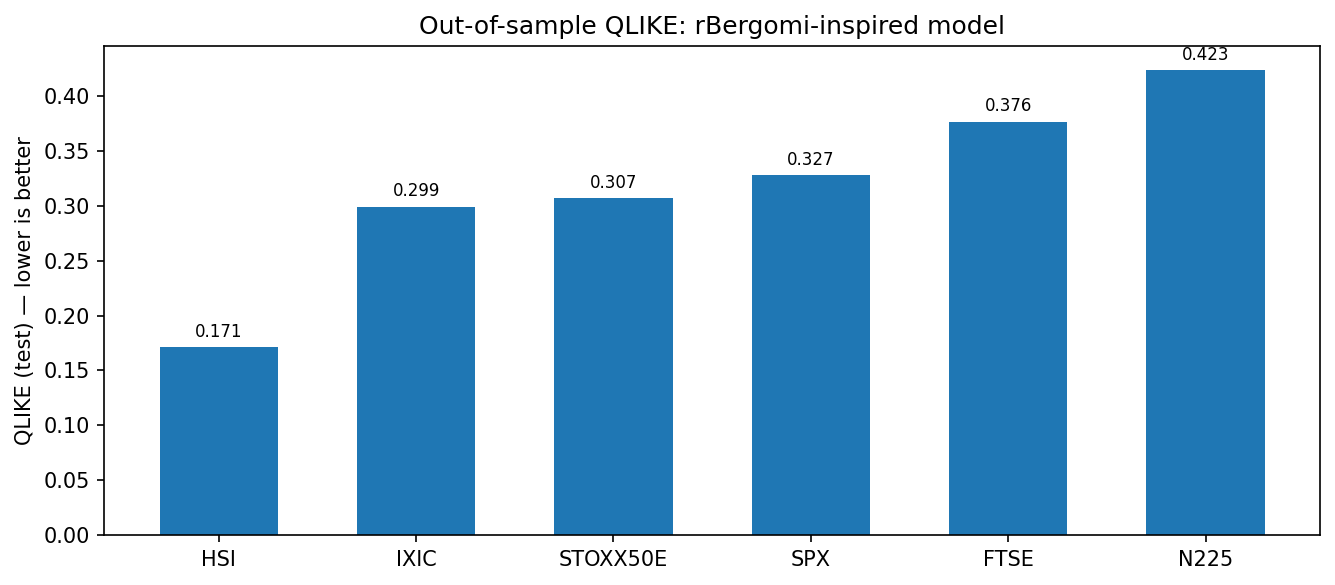

Saved: /content/drive/MyDrive/thesis/results/figures/QLIKE_bars_rB_only.png


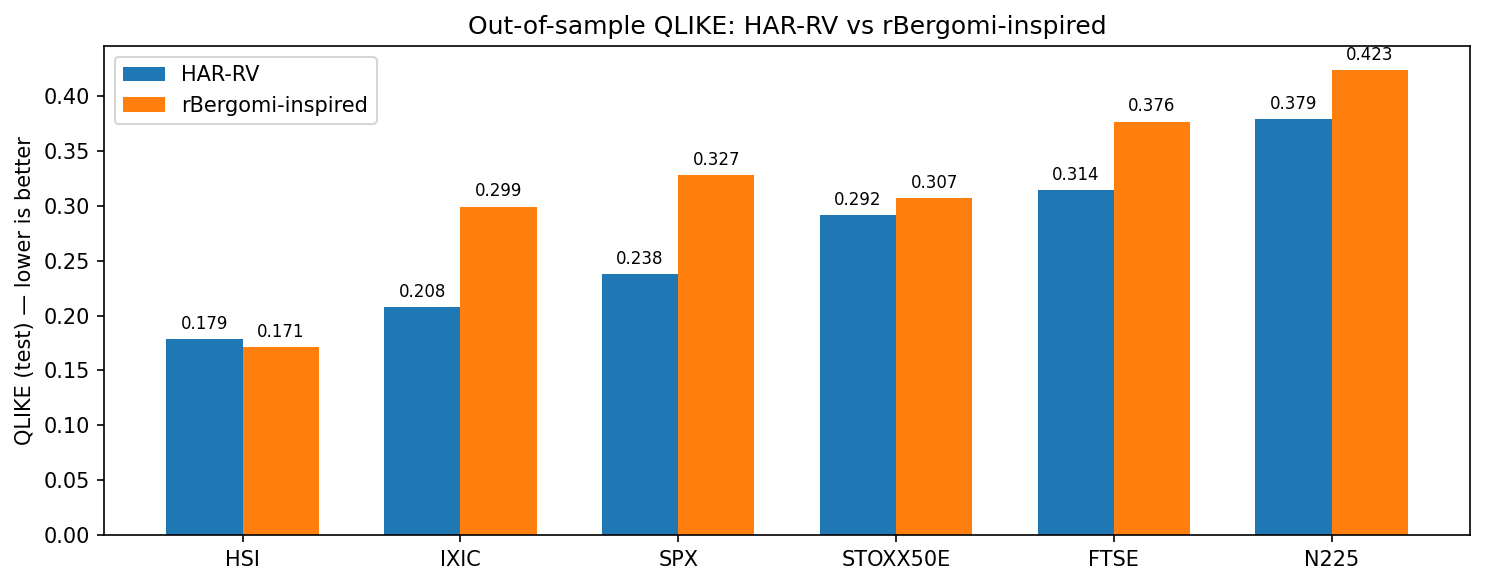

Saved: /content/drive/MyDrive/thesis/results/figures/QLIKE_bars_HAR_vs_rB.png


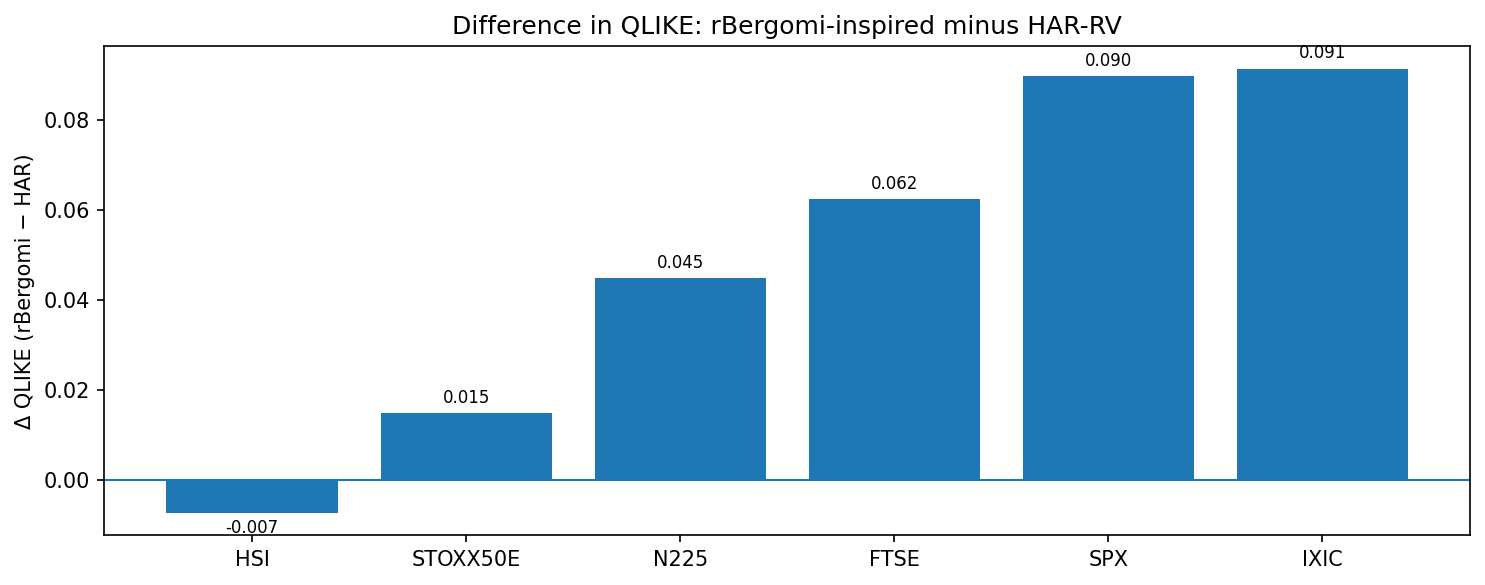

Saved: /content/drive/MyDrive/thesis/results/figures/Delta_QLIKE_rB_minus_HAR.png
Saved delta table: /content/drive/MyDrive/thesis/results/metrics/delta_QLIKE_rB_minus_HAR.csv


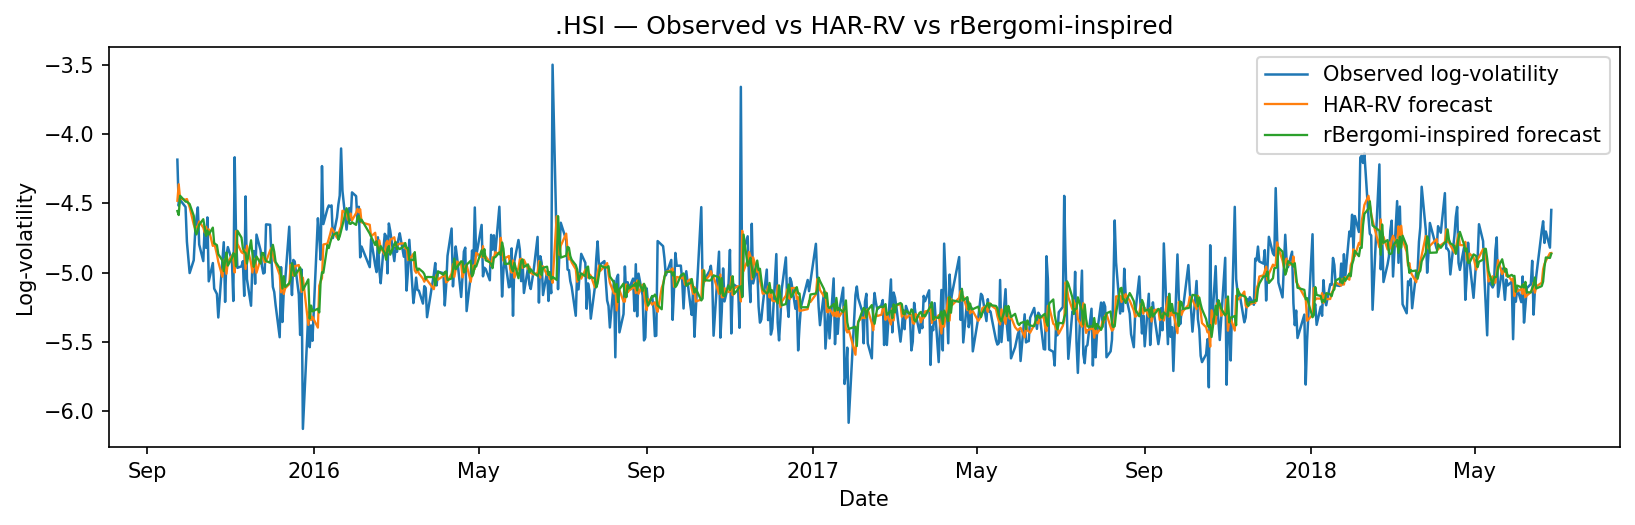

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_HSI_HAR_vs_rB.png


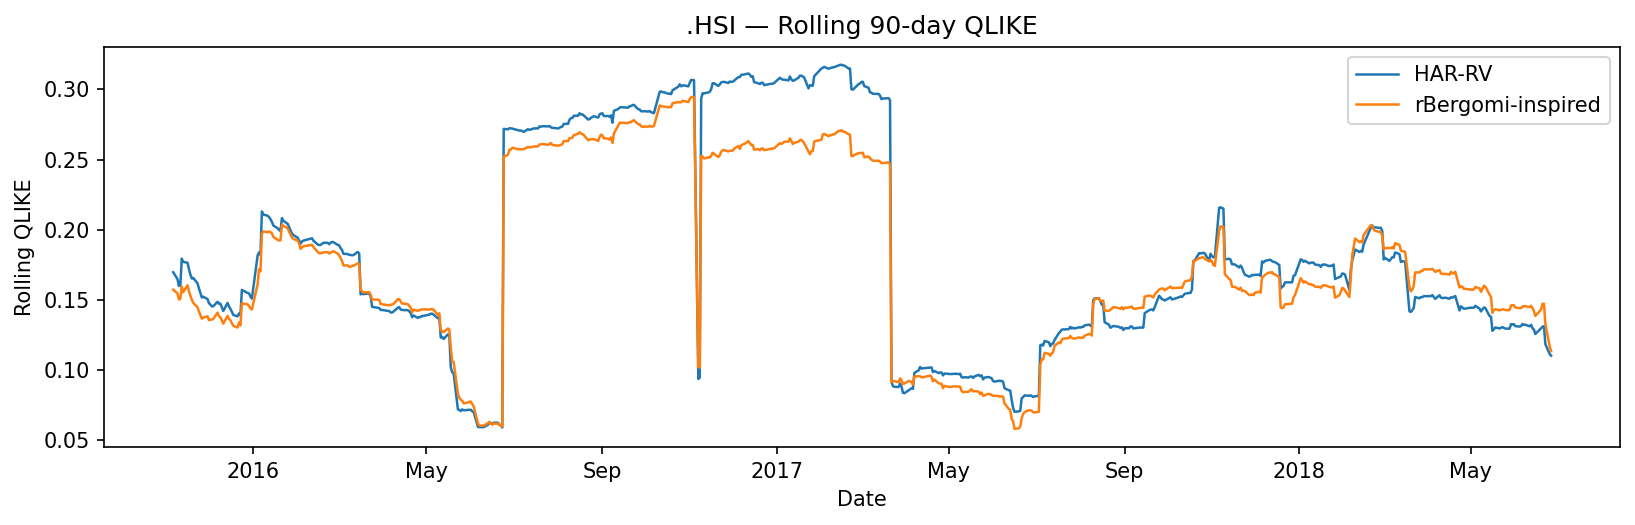

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_HSI_HAR_vs_rB.png


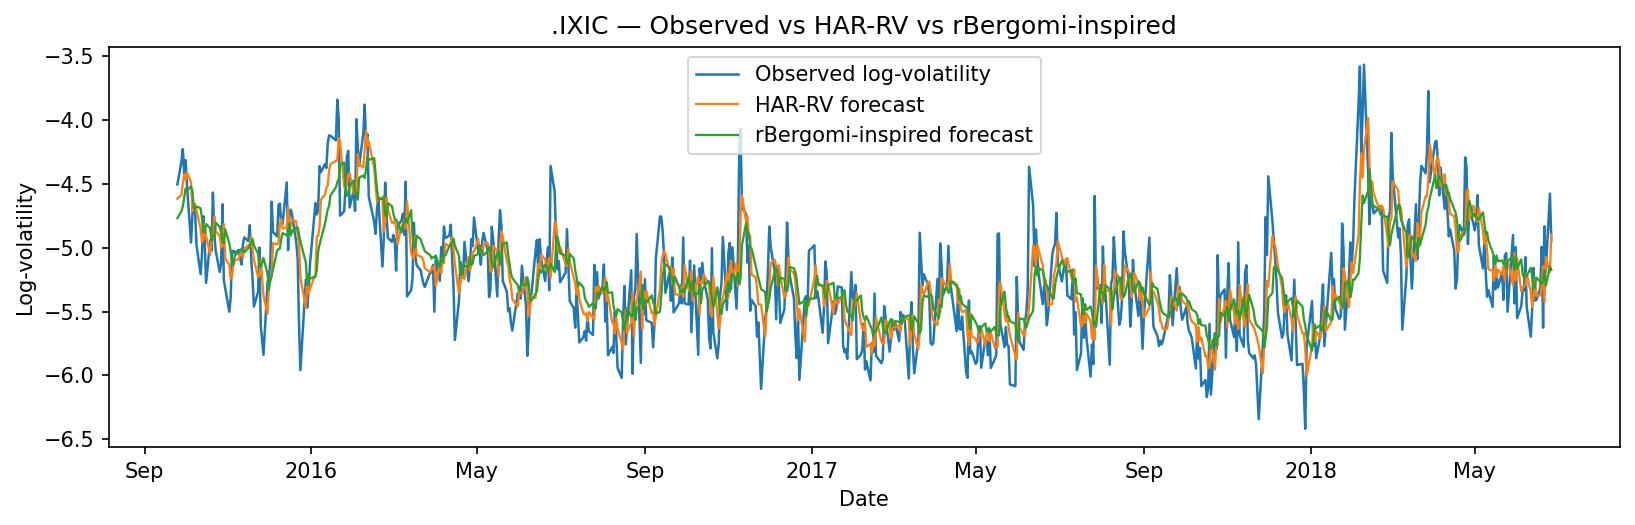

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_IXIC_HAR_vs_rB.png


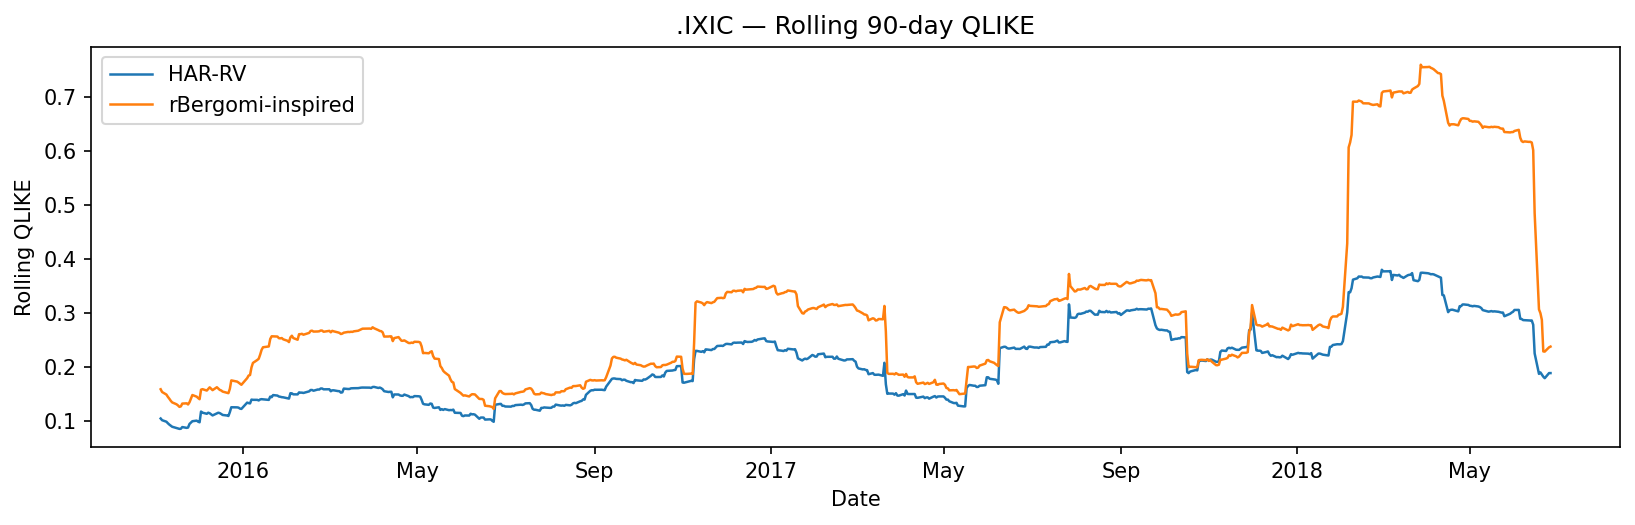

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_IXIC_HAR_vs_rB.png


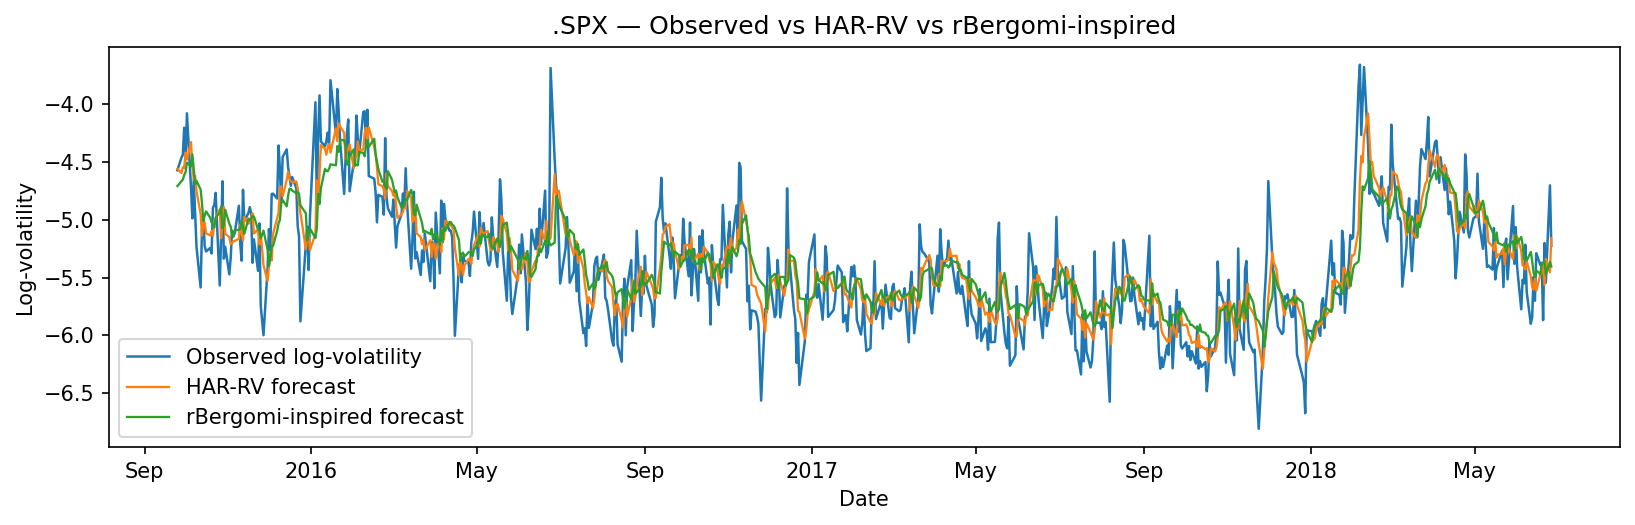

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_SPX_HAR_vs_rB.png


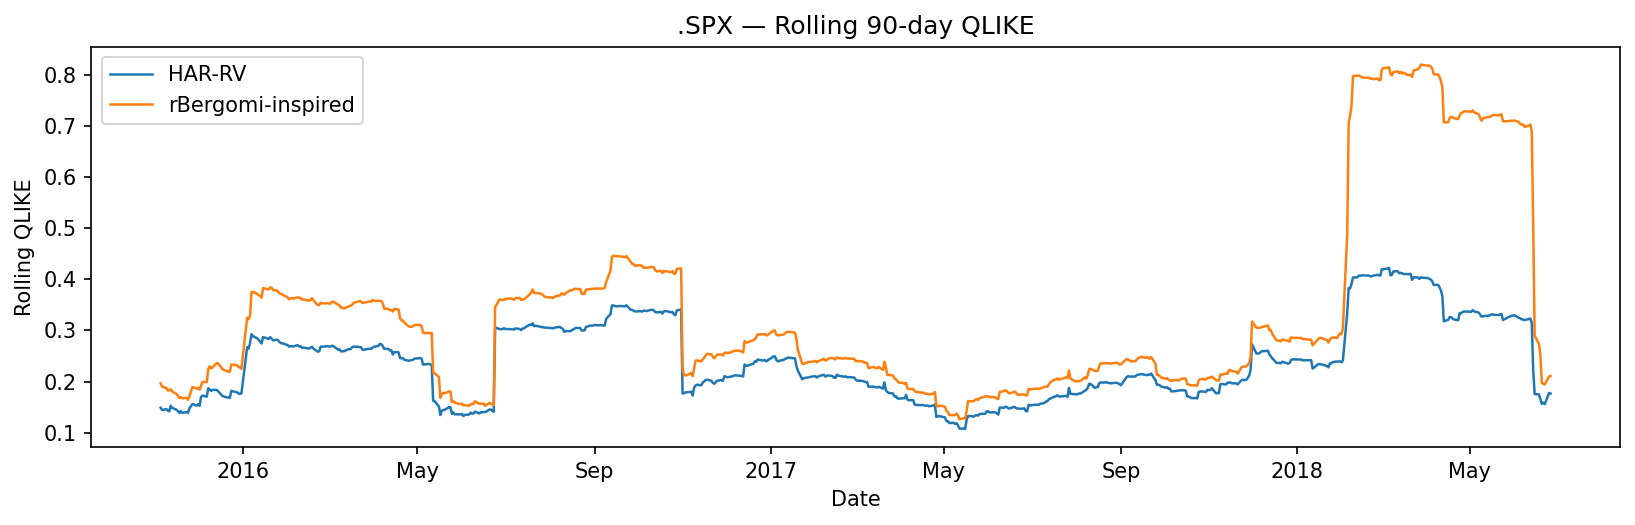

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_SPX_HAR_vs_rB.png


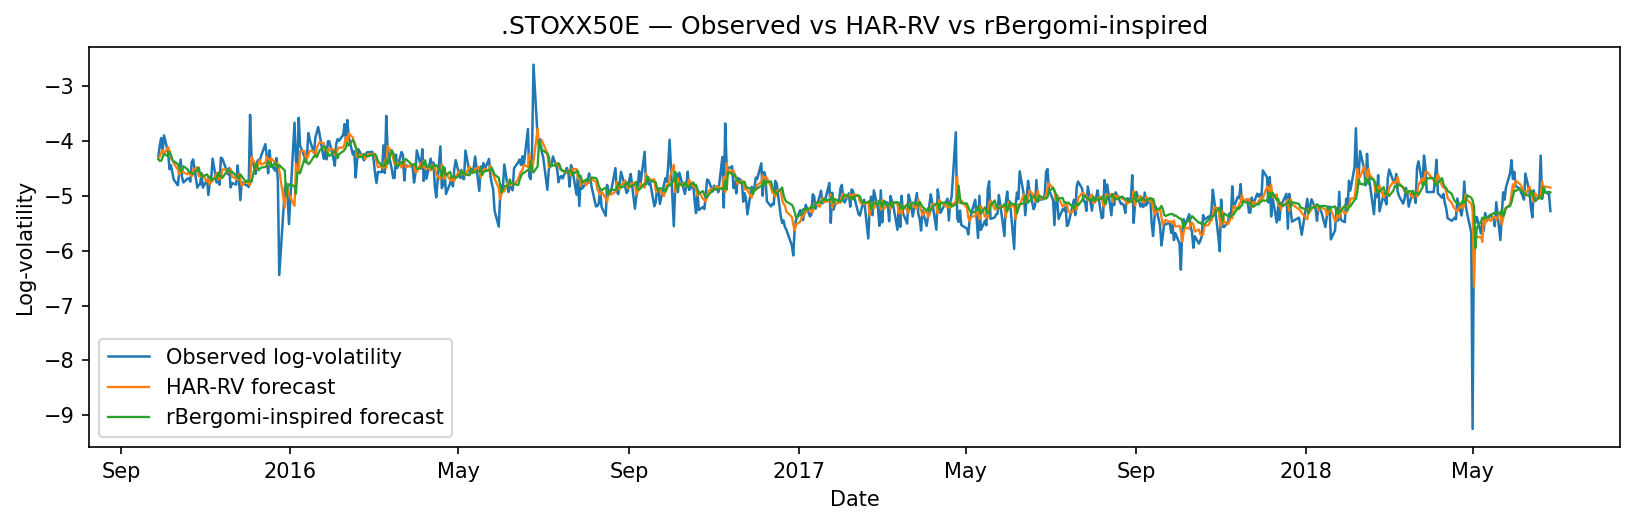

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_STOXX50E_HAR_vs_rB.png


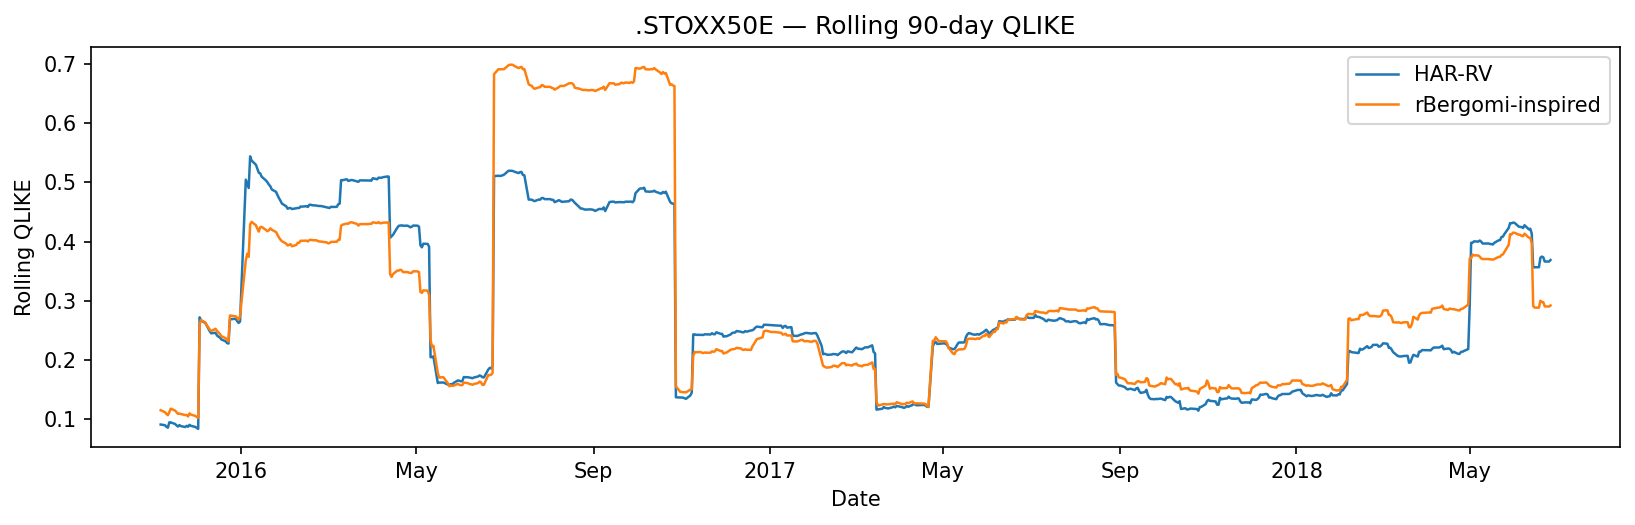

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_STOXX50E_HAR_vs_rB.png


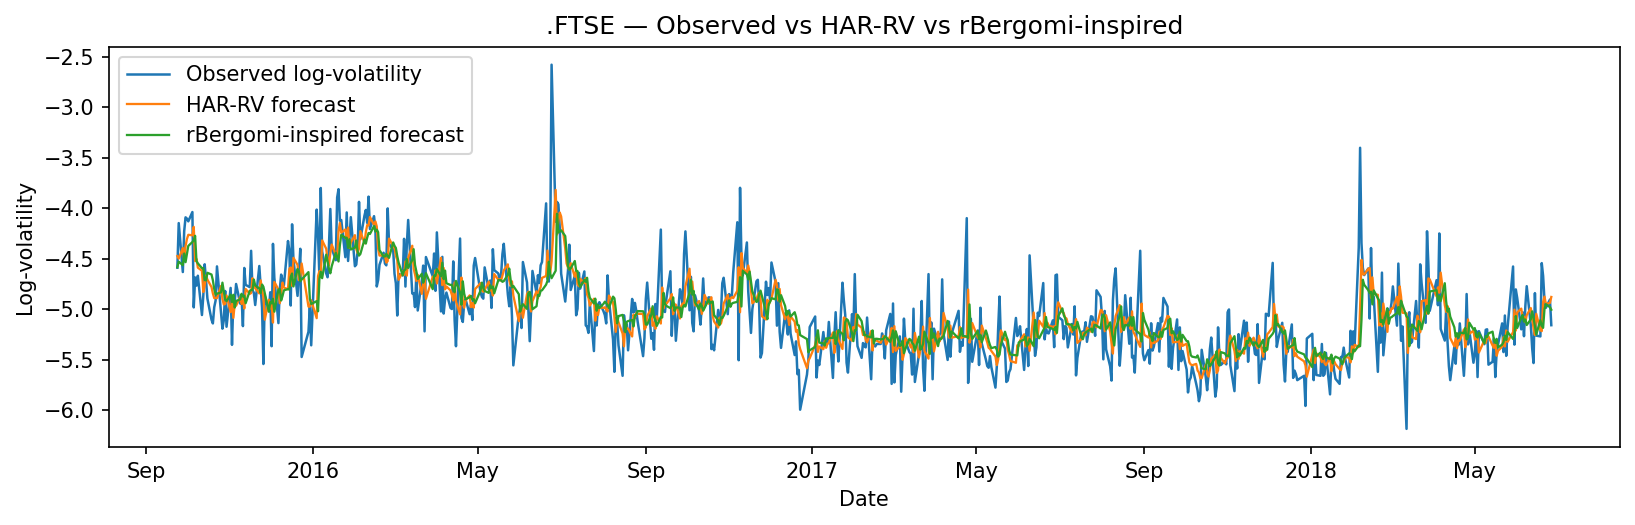

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_FTSE_HAR_vs_rB.png


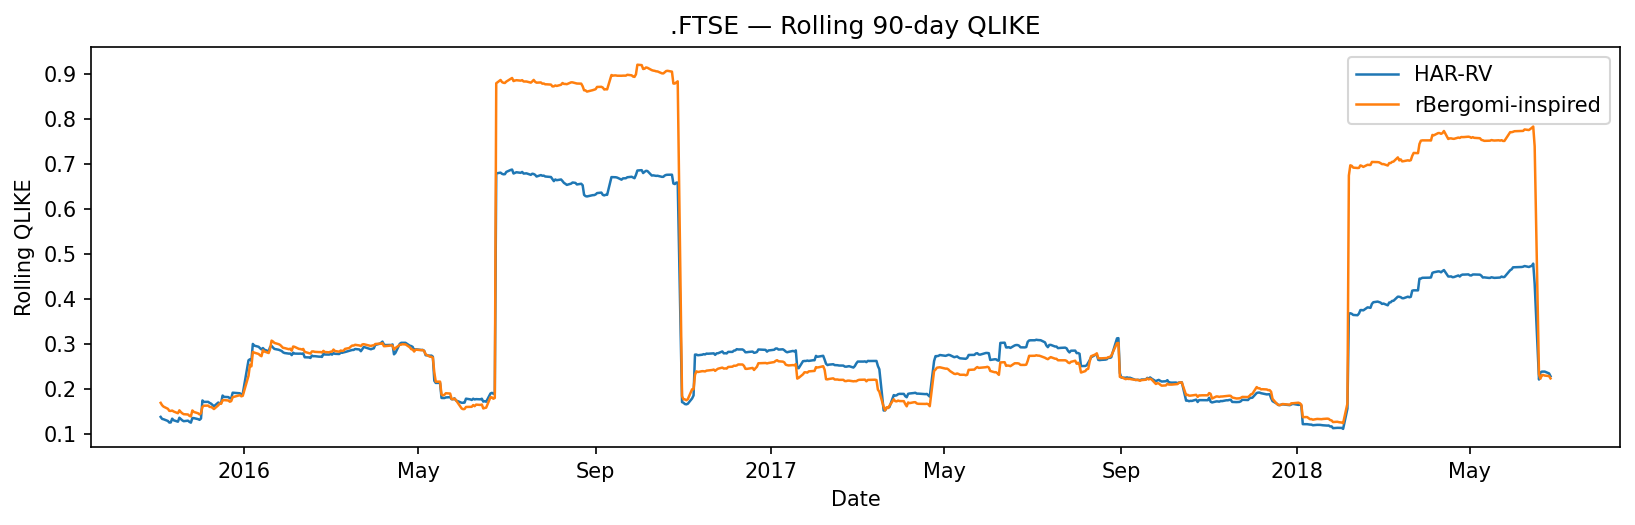

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_FTSE_HAR_vs_rB.png


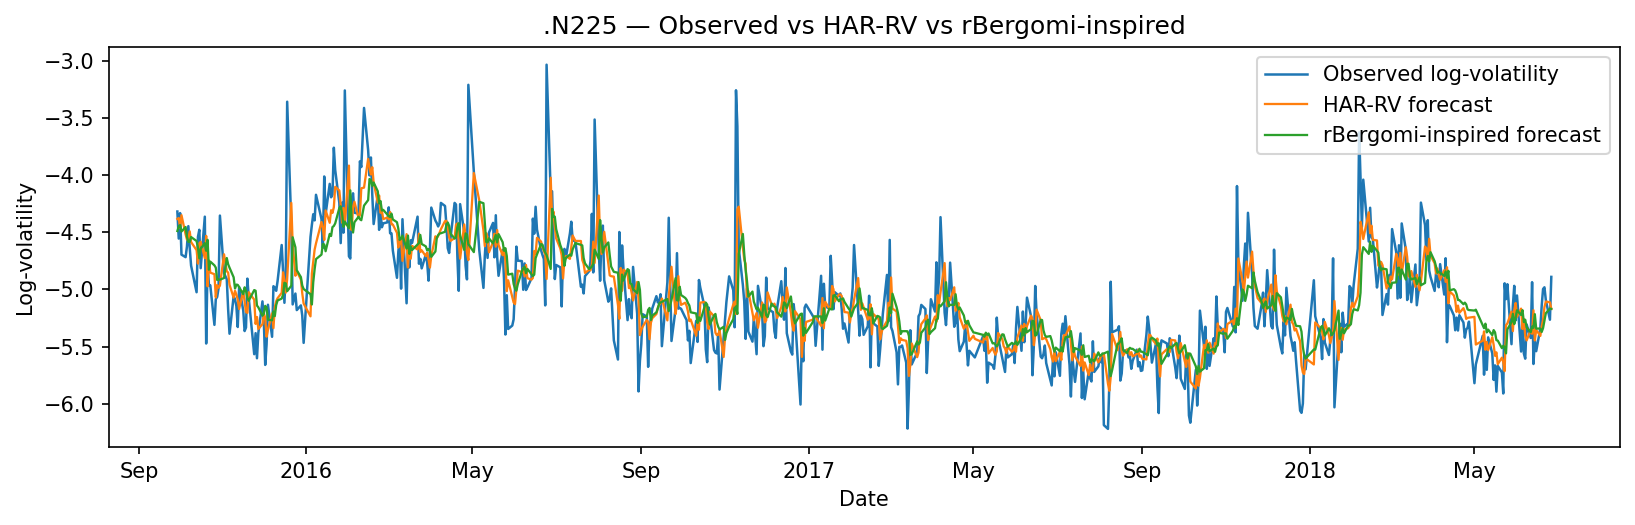

Saved: /content/drive/MyDrive/thesis/results/figures/test_lines_compare_N225_HAR_vs_rB.png


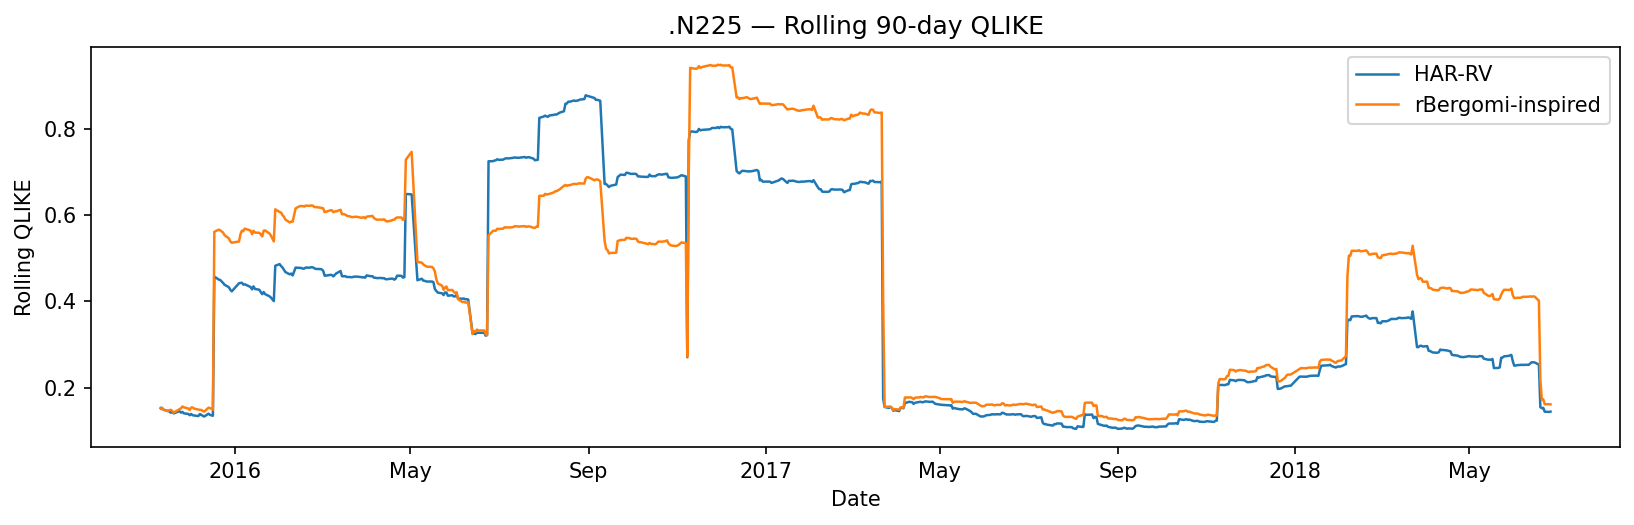

Saved: /content/drive/MyDrive/thesis/results/figures/rollingQLIKE_N225_HAR_vs_rB.png
Rough-Bergomi-inspired plots completed successfully.


In [4]:
# ============================================================
# ROUGH-BERGOMI-INSPIRED PLOTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HAR_METRICS = f"{RESULTS_DIR}/har_baseline_metrics.csv"
RB_SUMMARY = f"{RESULTS_DIR}/rbergomi_summary.csv"

WINDOW = 90


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def find_qlike_column(df, preferred_names):
    """
    Find a QLIKE test column robustly.
    """
    for name in preferred_names:
        if name in df.columns:
            return name

    candidates = [
        col for col in df.columns
        if "QLIKE" in col.upper() and "TEST" in col.upper()
    ]

    if not candidates:
        raise ValueError(
            f"No QLIKE test column found. Available columns: {list(df.columns)}"
        )

    return candidates[0]


def normalize_symbol(symbol):
    symbol = str(symbol).strip()
    return symbol if symbol.startswith(".") else f".{symbol}"


def clean_symbol_label(symbol):
    return str(symbol).replace(".", "")


def annotate_bars(ax, fmt="{:.3f}", signed=False):
    for patch in ax.patches:
        height = patch.get_height()

        if signed and height < 0:
            va = "top"
            offset = -3
        else:
            va = "bottom"
            offset = 3

        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va=va,
            fontsize=8,
            xytext=(0, offset),
            textcoords="offset points"
        )


def qlike_point_from_logvol(y_true_log, y_pred_log):
    var_true = np.exp(2.0 * y_true_log)
    var_pred = np.maximum(np.exp(2.0 * y_pred_log), 1e-12)

    ratio = np.clip(var_true / var_pred, 1e-300, 1e300)

    return ratio - np.log(ratio) - 1.0


def find_prediction_file(symbol, model):
    short = symbol.lstrip(".")

    if model == "HAR":
        candidates = [
            f"{PRED_DIR}/pred_test_{symbol}.csv",
            f"{PRED_DIR}/pred_test_{short}.csv",
        ]

    elif model == "rB":
        candidates = [
            f"{PRED_DIR}/pred_test_{symbol}_rB.csv",
            f"{PRED_DIR}/pred_test_{short}_rB.csv",
            f"{PRED_DIR}/pred_test_{symbol}_rBergomi.csv",
            f"{PRED_DIR}/pred_test_{short}_rBergomi.csv",
        ]

    else:
        candidates = []

    for path in candidates:
        if os.path.exists(path):
            return path

    return None


def find_prediction_column(df, model):
    if model == "HAR":
        candidates = ["y_pred_HAR", "y_pred_har"]

    elif model == "rB":
        candidates = [
            "y_pred_rB",
            "y_pred_rBergomi",
            "y_pred_rbergomi",
            "y_pred_RB",
        ]

    else:
        candidates = []

    for col in candidates:
        if col in df.columns:
            return col

    fallback = [
        col for col in df.columns
        if col.startswith("y_pred")
    ]

    if not fallback:
        raise ValueError(f"No prediction column found. Columns: {list(df.columns)}")

    return fallback[0]


# ------------------------------------------------------------
# Load metrics robustly
# ------------------------------------------------------------

har_raw = pd.read_csv(HAR_METRICS)
rb_raw = pd.read_csv(RB_SUMMARY)

print("HAR metrics columns:", list(har_raw.columns))
print("rB metrics columns:", list(rb_raw.columns))

har_qlike_col = find_qlike_column(
    har_raw,
    preferred_names=["HAR_QLIKE_test", "QLIKE_test", "HAR_QLIKE"]
)

rb_qlike_col = find_qlike_column(
    rb_raw,
    preferred_names=["QLIKE_test", "rB_QLIKE_test", "RB_QLIKE_test"]
)

har = har_raw[["Symbol", har_qlike_col]].rename(
    columns={har_qlike_col: "HAR_QLIKE_test"}
)

rb = rb_raw[["Symbol", rb_qlike_col]].rename(
    columns={rb_qlike_col: "rB_QLIKE_test"}
)

har["Symbol"] = har["Symbol"].apply(normalize_symbol)
rb["Symbol"] = rb["Symbol"].apply(normalize_symbol)

comparison = (
    har.merge(rb, on="Symbol", how="inner")
    .sort_values("HAR_QLIKE_test")
    .reset_index(drop=True)
)

if comparison.empty:
    raise RuntimeError("No common symbols between HAR and rBergomi metrics.")

display(comparison)


# ------------------------------------------------------------
# 1. rBergomi-only QLIKE bar chart
# ------------------------------------------------------------

rb_only = rb.sort_values("rB_QLIKE_test").reset_index(drop=True)

labels = rb_only["Symbol"].apply(clean_symbol_label)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 4), dpi=150)

ax.bar(x, rb_only["rB_QLIKE_test"], width=0.6)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("QLIKE (test) — lower is better")
ax.set_title("Out-of-sample QLIKE: rBergomi-inspired model")

annotate_bars(ax)

fig.tight_layout()

out_path = f"{FIG_DIR}/QLIKE_bars_rB_only.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")


# ------------------------------------------------------------
# 2. HAR vs rBergomi QLIKE bar chart
# ------------------------------------------------------------

labels = comparison["Symbol"].apply(clean_symbol_label)
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

ax.bar(
    x - width / 2,
    comparison["HAR_QLIKE_test"],
    width=width,
    label="HAR-RV"
)

ax.bar(
    x + width / 2,
    comparison["rB_QLIKE_test"],
    width=width,
    label="rBergomi-inspired"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("QLIKE (test) — lower is better")
ax.set_title("Out-of-sample QLIKE: HAR-RV vs rBergomi-inspired")

ax.legend()

annotate_bars(ax)

fig.tight_layout()

out_path = f"{FIG_DIR}/QLIKE_bars_HAR_vs_rB.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")


# ------------------------------------------------------------
# 3. Delta QLIKE: rBergomi minus HAR
# ------------------------------------------------------------

delta_df = comparison.copy()

delta_df["Delta_rB_minus_HAR"] = (
    delta_df["rB_QLIKE_test"]
    - delta_df["HAR_QLIKE_test"]
)

delta_df = (
    delta_df
    .sort_values("Delta_rB_minus_HAR")
    .reset_index(drop=True)
)

labels = delta_df["Symbol"].apply(clean_symbol_label)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

ax.bar(x, delta_df["Delta_rB_minus_HAR"])

ax.axhline(0.0, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Δ QLIKE (rBergomi − HAR)")
ax.set_title("Difference in QLIKE: rBergomi-inspired minus HAR-RV")

annotate_bars(ax, signed=True)

fig.tight_layout()

out_path = f"{FIG_DIR}/Delta_QLIKE_rB_minus_HAR.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

delta_csv = f"{RESULTS_DIR}/delta_QLIKE_rB_minus_HAR.csv"
delta_df.to_csv(delta_csv, index=False)

print(f"Saved: {out_path}")
print(f"Saved delta table: {delta_csv}")


# ------------------------------------------------------------
# 4. Overlays and rolling QLIKE
# ------------------------------------------------------------

for symbol in comparison["Symbol"].tolist():

    short = clean_symbol_label(symbol)

    har_path = find_prediction_file(symbol, model="HAR")
    rb_path = find_prediction_file(symbol, model="rB")

    if har_path is None or rb_path is None:
        print(f"Skipping {symbol}: missing HAR or rBergomi prediction file.")
        continue

    har_pred = pd.read_csv(
        har_path,
        parse_dates=["Date", "Date_target"]
    ).dropna(subset=["Date_target"]).sort_values("Date_target")

    rb_pred = pd.read_csv(
        rb_path,
        parse_dates=["Date", "Date_target"]
    ).dropna(subset=["Date_target"]).sort_values("Date_target")

    try:
        har_pred_col = find_prediction_column(har_pred, model="HAR")
        rb_pred_col = find_prediction_column(rb_pred, model="rB")

    except ValueError as error:
        print(f"Skipping {symbol}: {error}")
        continue

    if "y_true" not in har_pred.columns or "y_true" not in rb_pred.columns:
        print(f"Skipping {symbol}: y_true column missing.")
        continue

    merged = har_pred[
        ["Date_target", "y_true", har_pred_col]
    ].merge(
        rb_pred[["Date_target", "y_true", rb_pred_col]],
        on="Date_target",
        how="inner",
        suffixes=("_HAR", "_rB")
    )

    if merged.empty:
        print(f"Skipping {symbol}: no common dates.")
        continue

    observed_col = "y_true_HAR"
    har_col = har_pred_col
    rb_col = rb_pred_col

    # --------------------------------------------------------
    # Observed vs forecasts
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(11, 3.6), dpi=150)

    ax.plot(
        merged["Date_target"],
        merged[observed_col],
        label="Observed log-volatility",
        linewidth=1.2
    )

    ax.plot(
        merged["Date_target"],
        merged[har_col],
        label="HAR-RV forecast",
        linewidth=1.1
    )

    ax.plot(
        merged["Date_target"],
        merged[rb_col],
        label="rBergomi-inspired forecast",
        linewidth=1.1
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

    ax.set_title(f"{symbol} — Observed vs HAR-RV vs rBergomi-inspired")
    ax.set_xlabel("Date")
    ax.set_ylabel("Log-volatility")

    ax.legend()

    fig.tight_layout()

    out_path = f"{FIG_DIR}/test_lines_compare_{short}_HAR_vs_rB.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")

    # --------------------------------------------------------
    # Rolling QLIKE
    # --------------------------------------------------------

    qlike_har = qlike_point_from_logvol(
        merged[observed_col].to_numpy(),
        merged[har_col].to_numpy()
    )

    qlike_rb = qlike_point_from_logvol(
        merged[observed_col].to_numpy(),
        merged[rb_col].to_numpy()
    )

    rolling_har = pd.Series(
        qlike_har,
        index=merged["Date_target"]
    ).rolling(WINDOW, min_periods=30).mean()

    rolling_rb = pd.Series(
        qlike_rb,
        index=merged["Date_target"]
    ).rolling(WINDOW, min_periods=30).mean()

    fig, ax = plt.subplots(figsize=(11, 3.6), dpi=150)

    ax.plot(
        rolling_har.index,
        rolling_har.values,
        label="HAR-RV",
        linewidth=1.2
    )

    ax.plot(
        rolling_rb.index,
        rolling_rb.values,
        label="rBergomi-inspired",
        linewidth=1.2
    )

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

    ax.set_title(f"{symbol} — Rolling {WINDOW}-day QLIKE")
    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling QLIKE")

    ax.legend()

    fig.tight_layout()

    out_path = f"{FIG_DIR}/rollingQLIKE_{short}_HAR_vs_rB.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")

print("Rough-Bergomi-inspired plots completed successfully.")